# Exercises Week 7 — ReLU Geodesics

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

## Part 1 — Verify θ₁=7, θ₂=1/7 fits the data equally well

In [2]:
def relu(z):
    return np.maximum(0, z)

def f(x, theta1, theta2):
    return theta2 * relu(theta1 * x)

x1, y1 = -1, 0
x2, y2 =  1, 1

for t1, t2 in [(1, 1), (7, 1/7)]:
    print(f"θ₁={t1}, θ₂={t2:.4f}:")
    print(f"  f({x1}) = {f(x1, t1, t2):.4f}  (expected {y1})")
    print(f"  f({x2}) = {f(x2, t1, t2):.4f}  (expected {y2})")
    print()

θ₁=1, θ₂=1.0000:
  f(-1) = 0.0000  (expected 0)
  f(1) = 1.0000  (expected 1)

θ₁=7, θ₂=0.1429:
  f(-1) = 0.0000  (expected 0)
  f(1) = 1.0000  (expected 1)



## Part 2 — Finite-sample metric G̅_θ

The Jacobian of f w.r.t. θ = (θ₁, θ₂) at input x is:

$$\mathbf{J}_\theta(\mathbf{x}) = \begin{pmatrix} \theta_2 x \cdot \mathbf{1}[\theta_1 x > 0] \\ \text{ReLU}(\theta_1 x) \end{pmatrix}$$

giving:

$$G_\theta(\mathbf{x}) = x^2 \cdot \mathbf{1}[\theta_1 x > 0] \begin{pmatrix} \theta_2^2 & \theta_1\theta_2 \\ \theta_1\theta_2 & \theta_1^2 \end{pmatrix}$$

Averaging over x₁=−1 and x₂=1 (both have x²=1, and exactly one indicator is active regardless of sign of θ₁):

$$\bar{\mathbf{G}}_\theta = \frac{1}{2}\begin{pmatrix} \theta_2^2 & \theta_1\theta_2 \\ \theta_1\theta_2 & \theta_1^2 \end{pmatrix}$$

Note: this matrix is **rank-1** (determinant = 0), so it is singular. We use discrete path-energy minimization to find the geodesic.

In [6]:
def G_metric_7_4(theta):
    """Finite-sample Riemannian metric at theta = (theta1, theta2)."""
    t1, t2 = theta
    return 0.5 * np.array([[t2**2, t1*t2],
                            [t1*t2, t1**2]])

# Verify metric at theta=(1,1) and theta=(7, 1/7)
for t in [(1, 1), (7, 1/7)]:
    print(f"G at θ=({t[0]}, {t[1]:.4f}):")
    print(G_metric_7_4(t))
    print()

G at θ=(1, 1.0000):
[[0.5 0.5]
 [0.5 0.5]]

G at θ=(7, 0.1429):
[[1.02040816e-02 5.00000000e-01]
 [5.00000000e-01 2.45000000e+01]]



## Part 3 — Geodesic via discrete path-energy minimisation

We minimise the discrete path energy:

$$E(\gamma) = \sum_{i=0}^{N} \Delta\theta_i^\top \, \bar{\mathbf{G}}_{\bar{\theta}_i} \, \Delta\theta_i$$

where $\Delta\theta_i = \theta_{i+1} - \theta_i$ and $\bar{\theta}_i$ is the midpoint. The two endpoints are fixed; the $N$ interior waypoints are the optimisation variables.

In [12]:
def path_energy(free_flat, G_metric, theta_start, theta_end, N):
    """Discrete Riemannian path energy with fixed endpoints."""
    free = free_flat.reshape(N, 2)
    path = np.vstack([theta_start, free, theta_end])
    energy = 0.0
    for i in range(len(path) - 1):
        delta = path[i + 1] - path[i]
        mid   = 0.5 * (path[i] + path[i + 1])
        G     = G_metric(mid)
        energy += delta @ G @ delta
    return energy

In [13]:
# --- Endpoints ---
theta_A = np.array([1.0,  1.0])
theta_B = np.array([21.0, 3.0 / 7.0])

N = 100  # interior waypoints

# Linear interpolation as initial guess
t_vals   = np.linspace(0, 1, N + 2)[1:-1]
init_pts = np.outer(1 - t_vals, theta_A) + np.outer(t_vals, theta_B)

result = minimize(
    path_energy,
    init_pts.flatten(),
    args=(G_metric_7_4, theta_A, theta_B, N),
    method='L-BFGS-B',
    options={'maxiter': 20000, 'ftol': 1e-15, 'gtol': 1e-10},
)

opt_pts       = result.x.reshape(N, 2)
geodesic_path = np.vstack([theta_A, opt_pts, theta_B])
linear_path   = np.vstack([theta_A, init_pts, theta_B])

print(f"Optimisation converged: {result.success}")
print(f"Geodesic energy : {result.fun:.6f}")
print(f"Linear    energy: {path_energy(init_pts.flatten(), G_metric_7_4, theta_A, theta_B, N):.6f}")

Optimisation converged: False
Geodesic energy : 0.389114
Linear    energy: 0.532342


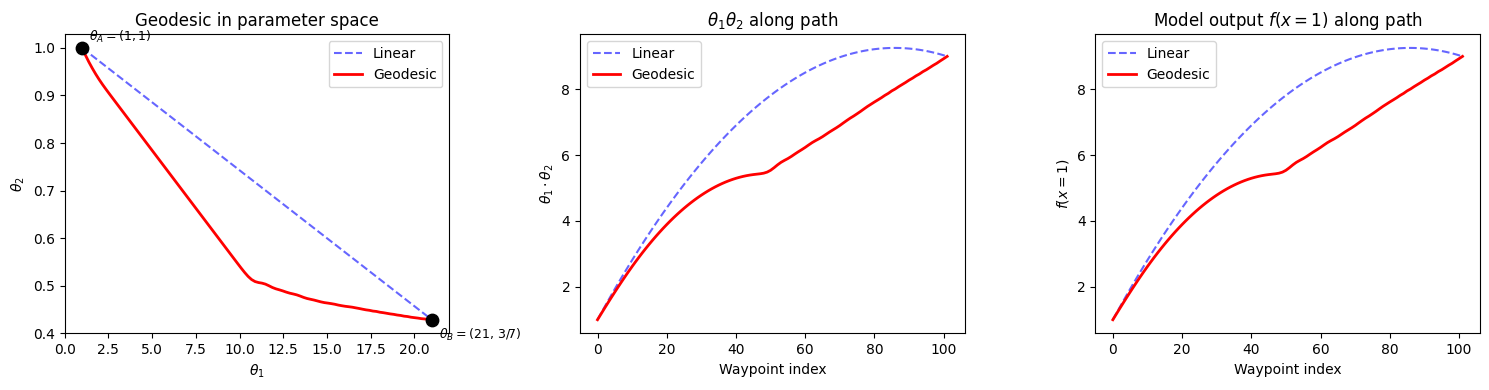

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Plot 1: path in (θ₁, θ₂) space ---
ax = axes[0]
ax.plot(linear_path[:, 0],  linear_path[:, 1],  'b--', alpha=0.6, label='Linear')
ax.plot(geodesic_path[:, 0], geodesic_path[:, 1], 'r-',  lw=2,    label='Geodesic')
ax.scatter([theta_A[0], theta_B[0]], [theta_A[1], theta_B[1]], s=80, c='k', zorder=5)
ax.annotate(r'$\theta_A=(1,1)$',       theta_A, textcoords='offset points', xytext=(5,  5), fontsize=9)
ax.annotate(r'$\theta_B=(21,\,3/7)$',  theta_B, textcoords='offset points', xytext=(5, -14), fontsize=9)
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')
ax.set_title('Geodesic in parameter space')
ax.legend()

# --- Plot 2: θ₁·θ₂ along path (the "invariant" of the model) ---
ax2 = axes[1]
ax2.plot(linear_path[:, 0]   * linear_path[:, 1],   'b--', alpha=0.6, label='Linear')
ax2.plot(geodesic_path[:, 0] * geodesic_path[:, 1], 'r-',  lw=2,     label='Geodesic')
ax2.set_xlabel('Waypoint index')
ax2.set_ylabel(r'$\theta_1 \cdot \theta_2$')
ax2.set_title(r'$\theta_1\theta_2$ along path')
ax2.legend()

# --- Plot 3: model output f(x=1) along path ---
ax3 = axes[2]
f_geo = geodesic_path[:, 1] * np.maximum(0, geodesic_path[:, 0] * 1)  # f(x=1)
f_lin = linear_path[:, 1]   * np.maximum(0, linear_path[:, 0]   * 1)
ax3.plot(f_lin, 'b--', alpha=0.6, label='Linear')
ax3.plot(f_geo, 'r-',  lw=2,     label='Geodesic')
ax3.set_xlabel('Waypoint index')
ax3.set_ylabel(r'$f(x=1)$')
ax3.set_title(r'Model output $f(x{=}1)$ along path')
ax3.legend()

plt.tight_layout()
plt.show()

In [14]:
def G_metric_7_5(theta):
    """Finite-sample Riemannian metric at theta = (theta1, theta2)."""
    t1, t2 = theta
    return 0.5 * np.array([[t2**2 * (1 - (np.tanh(t1)**2))**2, t2 * np.tanh(t1) * (1 - (np.tanh(t1)**2))],
                            [t2 * np.tanh(t1) * (1 - (np.tanh(t1)**2)), np.tanh(t1)**2]])

# Verify metric at theta=(1,1) and theta=(7, 1/7)
for t in [(1, 1), (7, 1/7)]:
    print(f"G at θ=({t[0]}, {t[1]:.4f}):")
    print(G_metric_7_5(t))
    print()

G at θ=(1, 1.0000):
[[0.08818922 0.159925  ]
 [0.159925   0.29001283]]

G at θ=(7, 0.1429):
[[1.12887790e-13 2.37578844e-07]
 [2.37578844e-07 4.99998337e-01]]



In [19]:
# --- Endpoints ---
theta_A = np.array([1.0,  1.0])
theta_B = np.array([21.0, 3.0 / 7.0])

N = 100  # interior waypoints

# Linear interpolation as initial guess
t_vals   = np.linspace(0, 1, N + 2)[1:-1]
init_pts = np.outer(1 - t_vals, theta_A) + np.outer(t_vals, theta_B)

result = minimize(
    path_energy,
    init_pts.flatten(),
    args=(G_metric_7_5, theta_A, theta_B, N),
    method='L-BFGS-B',
    options={'maxiter': 10000, 'ftol': 1e-15, 'gtol': 1e-10},
)

opt_pts       = result.x.reshape(N, 2)
geodesic_path = np.vstack([theta_A, opt_pts, theta_B])
linear_path   = np.vstack([theta_A, init_pts, theta_B])

print(f"Optimisation converged: {result.success}")
print(f"Geodesic energy : {result.fun:.6f}")
print(f"Linear    energy: {path_energy(init_pts.flatten(), G_metric_7_5, theta_A, theta_B, N):.6f}")

Optimisation converged: False
Geodesic energy : 0.000667
Linear    energy: 0.005442


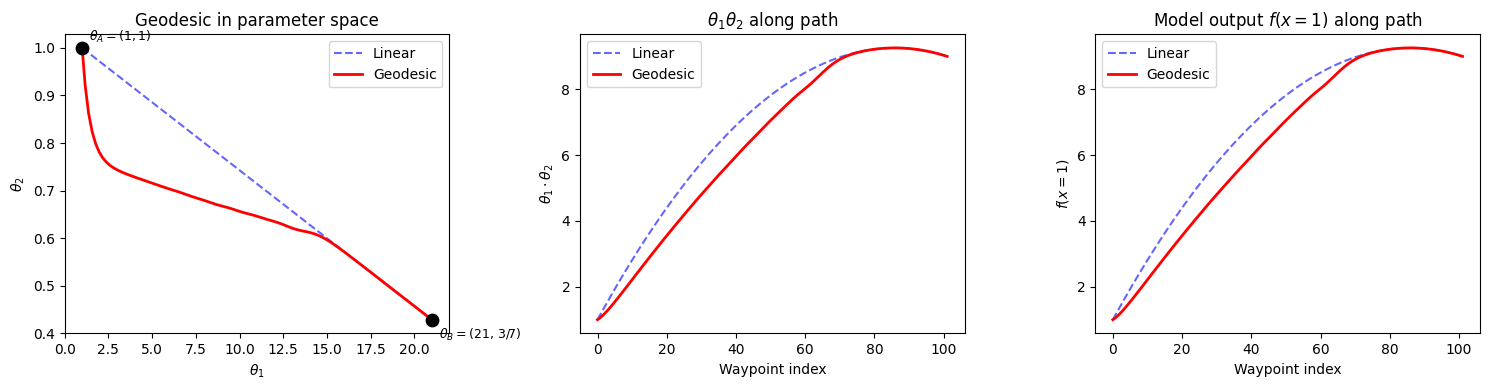

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Plot 1: path in (θ₁, θ₂) space ---
ax = axes[0]
ax.plot(linear_path[:, 0],  linear_path[:, 1],  'b--', alpha=0.6, label='Linear')
ax.plot(geodesic_path[:, 0], geodesic_path[:, 1], 'r-',  lw=2,    label='Geodesic')
ax.scatter([theta_A[0], theta_B[0]], [theta_A[1], theta_B[1]], s=80, c='k', zorder=5)
ax.annotate(r'$\theta_A=(1,1)$',       theta_A, textcoords='offset points', xytext=(5,  5), fontsize=9)
ax.annotate(r'$\theta_B=(21,\,3/7)$',  theta_B, textcoords='offset points', xytext=(5, -14), fontsize=9)
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')
ax.set_title('Geodesic in parameter space')
ax.legend()

# --- Plot 2: θ₁·θ₂ along path (the "invariant" of the model) ---
ax2 = axes[1]
ax2.plot(linear_path[:, 0]   * linear_path[:, 1],   'b--', alpha=0.6, label='Linear')
ax2.plot(geodesic_path[:, 0] * geodesic_path[:, 1], 'r-',  lw=2,     label='Geodesic')
ax2.set_xlabel('Waypoint index')
ax2.set_ylabel(r'$\theta_1 \cdot \theta_2$')
ax2.set_title(r'$\theta_1\theta_2$ along path')
ax2.legend()

# --- Plot 3: model output f(x=1) along path ---
ax3 = axes[2]
f_geo = geodesic_path[:, 1] * np.maximum(0, geodesic_path[:, 0] * 1)  # f(x=1)
f_lin = linear_path[:, 1]   * np.maximum(0, linear_path[:, 0]   * 1)
ax3.plot(f_lin, 'b--', alpha=0.6, label='Linear')
ax3.plot(f_geo, 'r-',  lw=2,     label='Geodesic')
ax3.set_xlabel('Waypoint index')
ax3.set_ylabel(r'$f(x=1)$')
ax3.set_title(r'Model output $f(x{=}1)$ along path')
ax3.legend()

plt.tight_layout()
plt.show()